# Aula 01 - Do projeto de análise ao texto clássico

## Laboratório: estruturar um projeto de análise e construir as primeiras representações de texto

Este notebook foi refeito para acompanhar os slides atualizados da Aula 01, aplicando cada técnica
a um corpus real: **letras de música** (`data/Songs.csv`), com 745 músicas de 21 artistas. Na
**Parte 0**, aplicamos o roteiro de projeto de análise ao minicaso de estudo de estilo lírico. Nas
**Partes 1 a 7**, transformamos letras em representações clássicas — tokenização, n-gramas,
bag-of-words, TF-IDF, similaridade, LSA, K-Means, sentimento léxico e entidades —
usando as mesmas bibliotecas reais (`scikit-learn`, `vaderSentiment`, `spaCy`) vistas nos slides.

## O que você vai fazer

1. Definir o objetivo analítico do minicaso e auditar o corpus antes de vetorizar.
2. Transformar letras em tokens, n-gramas e vetores (BoW, TF-IDF).
3. Comparar similaridade de cosseno, Jaccard e Euclidiana entre músicas.
4. Selecionar um subconjunto balanceado de artistas e explorar agrupamentos temáticos sem
   rótulos com LSA e K-Means.
5. Calcular sentimento léxico (VADER) e extrair candidatos a entidades (spaCy) das letras.

## Como trabalhar

Execute as células em ordem. Antes de alterar um parâmetro, escreva uma hipótese. Depois da
saída, registre o que mudou e leia exemplos reais do corpus. Os números aqui vêm de um corpus
pequeno e específico (letras de música em inglês); não generalize para outros domínios de texto.

> **Pergunta-guia:** qual informação linguística cada representação preserva e qual informação
> ela perde, quando aplicada a um texto criativo como uma letra de música?


In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import jaccard_score
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR
while not (ROOT / 'pyproject.toml').exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError('Execute o notebook a partir do repositório do curso.')
    ROOT = ROOT.parent

DATA_PATH = NOTEBOOK_DIR / 'data' / 'Songs.csv'
OUTPUT_PATH = ROOT / 'artifacts' / 'aula05'
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
RANDOM_SEED = 42
pd.set_option('display.max_colwidth', 80)

songs_raw = pd.read_csv(DATA_PATH)
print('Arquivo:', DATA_PATH)
print('Formato bruto:', songs_raw.shape)
display(songs_raw.head(3))


Arquivo: /home/marco/mba_genai/DSLLM/aula05/data/Songs.csv
Formato bruto: (745, 3)


,Artist,Title,Lyrics
0,Taylor Swift,cardigan,"Vintage tee, brand new phone\nHigh heels on cobblestones\nWhen you are young..."
1,Taylor Swift,exile,"I can see you standing, honey\nWith his arms around your body\nLaughin', but..."
2,Taylor Swift,Lover,"We could leave the Christmas lights up 'til January\nAnd this is our place, ..."


## 0. Passo a passo do projeto: objetivo analítico

Antes de qualquer código de NLP, aplicamos o roteiro visto na Parte 1 dos slides: dados que já
temos, o que queremos entender e o que hoje demora muito para analisar manualmente.

**Pergunta de negócio (minicaso):** que sinais lexicais simples e auditáveis (vocabulário, tópicos
latentes, tom emocional, entidades citadas) ajudam a caracterizar o "estilo" de um artista a
partir da letra de suas músicas, sem exigir julgamento subjetivo de "qualidade"?

**Objetivo analítico desta aula:**

- **Pergunta:** o vocabulário e o tom de uma letra de música permitem identificar seu autor e
  agrupar músicas por temas latentes?
- **População:** 745 músicas de 21 artistas, coletadas de um agregador de letras (`Songs.csv`).
- **Decisão que muda com a resposta:** que representação de texto (contagem, TF-IDF, léxico)
  vale a pena usar antes de investir em modelos mais caros (vistos nas próximas aulas).

`Songs.csv` não tem uma ficha de dados formal (*data card*) porém, contém são letras de música em inglês, extraídas de um site de letras, sem informação de ano, álbum ou gênero musical. 


In [2]:
songs_raw['n_words'] = songs_raw['Lyrics'].str.split().str.len()
print('Valores ausentes por coluna:')
print(songs_raw.isna().sum())
print()
print('Músicas por artista:')
display(songs_raw['Artist'].value_counts())
print()
print('Distribuição do tamanho da letra (em palavras):')
display(songs_raw['n_words'].describe())


Valores ausentes por coluna:
Artist     0
Title      0
Lyrics     0
n_words    0
dtype: int64

Músicas por artista:


Artist
Taylor Swift          50
Billie Eilish         50
David Bowie           50
Billy Joel            50
Eric Clapton          50
Leonard Cohen         50
Bruce Springsteen     40
The Beatles           35
Vance Joy             30
Lana Del Rey          30
Bryan Adams           30
Nat King Cole         30
​twenty one pilots    30
Ray LaMontagne        30
John Denver           30
Frank Sinatra         30
Queen                 30
Elton John            30
George Michael        30
Ed Sheeran            20
Bob Dylan             20
Name: count, dtype: int64


Distribuição do tamanho da letra (em palavras):


count     745.000000
mean      276.260403
std       129.230505
min         1.000000
25%       189.000000
50%       255.000000
75%       340.000000
max      1386.000000
Name: n_words, dtype: float64

### Checklist antes de seguir

- [ ] Sei quantas músicas e artistas o corpus tem, e que a base não tem ficha de dados formal.
- [ ] Sei que a coluna `Lyrics` pode conter texto colado sem tratamento (letras extraídas da web).
- [ ] Tenho uma hipótese sobre o que pode estar "sujo" no texto antes de vetorizar (ver Parte 1).
- [ ] Sei qual pergunta analítica este notebook tenta responder (Parte 0, acima).


## 1. Conhecer os dados: auditoria antes de modelar

Como visto nos slides, nenhum texto deve virar vetor sem antes ser inspecionado. Vamos checar
três coisas: (a) duplicidade de músicas, (b) letras anormalmente curtas e (c) padrões repetidos
suspeitos de raspagem de dados (*scraping*) que não fazem parte da letra em si.


In [3]:
# (a) duplicidade de música (mesmo artista + título)
duplicated = songs_raw.duplicated(subset=['Artist', 'Title']).sum()
print('Duplicatas (Artist, Title):', duplicated)

# (b) letras anormalmente curtas
curtas = songs_raw.sort_values('n_words').head(3)
display(curtas[['Artist', 'Title', 'n_words']])

# (c) padrão repetido suspeito de raspagem: procuramos um trecho colado ao final da letra
suspeita = songs_raw['Lyrics'].str.contains('embedshare', case=False, na=False)
print('Músicas com o padrão "EmbedShare" colado ao final:', suspeita.sum(), 'de', len(songs_raw))
print()
print('Exemplo do final de uma letra afetada:')
print(repr(songs_raw.loc[suspeita, 'Lyrics'].iloc[0][-70:]))


Duplicatas (Artist, Title): 0


,Artist,Title,n_words
622,John Denver,The Ballad of Richard Nixon,1
94,Billie Eilish,!!!!!!!,23
482,Leonard Cohen,String Reprise/Treaty,44


Músicas com o padrão "EmbedShare" colado ao final: 525 de 745

Exemplo do final de uma letra afetada:
'u put me on and said I was your favorite142EmbedShare URLCopyEmbedCopy'


### O que a auditoria encontrou

- **1 música praticamente vazia** ("The Ballad of Richard Nixon", John Denver, poucas palavras) —
  não carrega sinal lexical suficiente e deve ser descartada.
- **525 de 745 letras (≈70%)** terminam com um trecho colado do site de origem
  (`<número>EmbedShare URLCopyEmbedCopy`), que **não faz parte da letra**. É um artefato de
  raspagem de dados.

Isso não é um detalhe cosmético: em um teste preliminar de classificação por artista, o termo
`"embedshare"` apareceu entre os termos mais preditivos para um dos artistas — porque o padrão
está presente em praticamente 100% das músicas de alguns artistas e ausente em outros, criando um
atalho artificial que nada tem a ver com estilo lírico. Vamos limpar isso agora, antes de vetorizar
qualquer coisa.


In [4]:
SCRAPING_ARTIFACT = re.compile(r'\d*embedshare urlcopyembedcopy\s*$', re.IGNORECASE)

def limpar_letra(texto: str) -> str:
    return SCRAPING_ARTIFACT.sub('', texto).strip()

songs = songs_raw.copy()
songs['Lyrics'] = songs['Lyrics'].apply(limpar_letra)
songs['n_words'] = songs['Lyrics'].str.split().str.len()
songs = songs[songs['n_words'] >= 10].reset_index(drop=True)

restante = songs['Lyrics'].str.contains('embedshare', case=False, na=False).sum()
print('Formato antes da limpeza:', songs_raw.shape, '-> depois:', songs.shape)
print('Músicas ainda com o artefato após limpeza:', restante)
assert restante == 0
assert songs['n_words'].min() >= 10
print('Auditoria concluída: corpus limpo pronto para as próximas etapas (variável `songs`).')


Formato antes da limpeza: (745, 4) -> depois: (744, 4)
Músicas ainda com o artefato após limpeza: 0
Auditoria concluída: corpus limpo pronto para as próximas etapas (variável `songs`).


## 2. Tokenização e n-gramas

Como visto nos slides, tokenização quebra o texto em unidades e n-gramas capturam sequências de
`n` tokens. Vamos aplicar isso a um verso real do corpus: a primeira linha de "cardigan"
(Taylor Swift).


In [5]:
verso = 'Vintage tee, brand new phone'
tokens = re.findall(r"\w+|[^\w\s]", verso)
print('tokens:', tokens)

def ngramas(tokens, n):
    return sorted({' '.join(tokens[i:i + n]) for i in range(len(tokens) - n + 1)})

palavras = [t.lower() for t in tokens if t.isalpha()]
print('unigramas:', ngramas(palavras, 1))
print('bigramas:', ngramas(palavras, 2))
print('trigramas:', ngramas(palavras, 3))


tokens: ['Vintage', 'tee', ',', 'brand', 'new', 'phone']
unigramas: ['brand', 'new', 'phone', 'tee', 'vintage']
bigramas: ['brand new', 'new phone', 'tee brand', 'vintage tee']
trigramas: ['brand new phone', 'tee brand new', 'vintage tee brand']


## 3. Selecionar um subconjunto balanceado de artistas

O corpus tem 21 artistas com quantidades desiguais de músicas. Para comparar representações de
forma mais controlada nas próximas seções (similaridade, LSA/K-Means, sentimento e entidades),
selecionamos os 6 artistas com mais músicas cada — todos com exatamente 50 músicas.


In [6]:
BALANCED_ARTISTS = [
    'Billie Eilish', 'Leonard Cohen', 'David Bowie',
    'Taylor Swift', 'Eric Clapton', 'Billy Joel',
]
balanced = songs[songs['Artist'].isin(BALANCED_ARTISTS)].reset_index(drop=True)
print('Subconjunto balanceado:', balanced.shape)
display(balanced['Artist'].value_counts())


Subconjunto balanceado: (300, 4)


Artist
Taylor Swift     50
Billie Eilish    50
David Bowie      50
Billy Joel       50
Eric Clapton     50
Leonard Cohen    50
Name: count, dtype: int64

## 4. Bag-of-words, TF-IDF e similaridade

Vamos representar duas músicas da mesma artista (Taylor Swift: "cardigan" e "exile") como
vetores e comparar com três métricas de similaridade vistas nos slides: cosseno, Jaccard e
distância Euclidiana.


In [7]:
ts = songs[songs['Artist'] == 'Taylor Swift']
doc_a = ts.loc[ts['Title'] == 'cardigan', 'Lyrics'].iloc[0]
doc_b = ts.loc[ts['Title'] == 'exile', 'Lyrics'].iloc[0]

# TF-IDF + cosseno
tfidf = TfidfVectorizer(stop_words='english')
tfidf_vecs = tfidf.fit_transform([doc_a, doc_b])
cos = cosine_similarity(tfidf_vecs[0], tfidf_vecs[1])[0, 0]

# Bag-of-words binário + Jaccard
count_bin = CountVectorizer(stop_words='english', binary=True)
bow_bin = count_bin.fit_transform([doc_a, doc_b]).toarray()
jac = jaccard_score(bow_bin[0], bow_bin[1])

# Bag-of-words de contagem + distância Euclidiana
count = CountVectorizer(stop_words='english')
bow = count.fit_transform([doc_a, doc_b]).toarray()
euc = euclidean_distances(bow[[0]], bow[[1]])[0, 0]

print('cardigan vs exile (Taylor Swift)')
print('cosseno (TF-IDF):', round(cos, 3))
print('Jaccard (BoW binário):', round(jac, 3))
print('Euclidiana (BoW contagem):', round(euc, 3))


cardigan vs exile (Taylor Swift)
cosseno (TF-IDF): 0.046
Jaccard (BoW binário): 0.039
Euclidiana (BoW contagem): 34.986


## 5. Exploração sem rótulos: LSA e K-Means

Agora ignoramos o rótulo de artista e perguntamos: o vocabulário das letras, sozinho, forma
grupos naturais? Reduzimos o TF-IDF a 2 dimensões com LSA (`TruncatedSVD`) e aplicamos K-Means
com 6 clusters (o mesmo número de artistas do subconjunto), só para comparação visual.


Matriz TF-IDF: (300, 2203)


Artista x cluster (contagem de músicas):


cluster,0,1,2,3,4,5
Artist,,,,,,
Billie Eilish,21,1,7,9,3,9
Billy Joel,15,1,9,13,2,10
David Bowie,6,2,24,16,0,2
Eric Clapton,12,1,17,18,0,2
Leonard Cohen,8,1,15,22,1,3
Taylor Swift,14,0,4,19,1,12


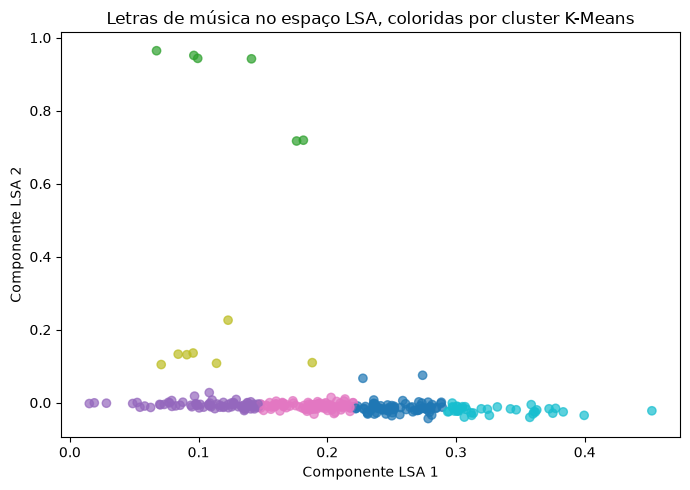

In [8]:
tfidf_geral = TfidfVectorizer(stop_words='english', max_df=0.9, min_df=2)
X = tfidf_geral.fit_transform(balanced['Lyrics'])
print('Matriz TF-IDF:', X.shape)

lsa = TruncatedSVD(n_components=2, random_state=RANDOM_SEED)
coords = lsa.fit_transform(X)

kmeans = KMeans(n_clusters=6, n_init=10, random_state=RANDOM_SEED)
clusters = kmeans.fit_predict(coords)
balanced_clusters = balanced.copy()
balanced_clusters['cluster'] = clusters

print('Artista x cluster (contagem de músicas):')
display(pd.crosstab(balanced_clusters['Artist'], balanced_clusters['cluster']))

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=clusters, cmap='tab10', alpha=0.7)
ax.set_xlabel('Componente LSA 1')
ax.set_ylabel('Componente LSA 2')
ax.set_title('Letras de música no espaço LSA, coloridas por cluster K-Means')
fig.tight_layout()
fig.savefig(OUTPUT_PATH / 'lsa_kmeans_musicas.png', dpi=150)
plt.show()


**Leitura do resultado:** os clusters não recuperam a identidade do artista. Dois clusters
grandes (0 e 3) reúnem músicas das seis artistas quase igualmente — sinal de que boa parte do
vocabulário lírico (amor, tempo, noite...) é compartilhado entre artistas e estilos. Já o
cluster 2 concentra sobretudo David Bowie, Eric Clapton e Leonard Cohen, sugerindo um
vocabulário mais próximo entre esses três (mesma geração/gênero musical). Os clusters 1 e 4 têm
poucas músicas no total e parecem outliers léxicos, não temas reais. Isso ilustra um limite
importante do LSA + K-Means sobre TF-IDF: ele agrupa por *palavras compartilhadas*, não por
*autoria* ou *significado* — os dois nem sempre coincidem.


## 6. Sentimento léxico com um pacote real (VADER)

Como nos slides (que usam `LeIA` para português), aqui usamos `vaderSentiment` — um analisador
léxico para inglês, o idioma das letras deste corpus. O escore `compound` varia de -1
(muito negativo) a +1 (muito positivo).


In [9]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analisador = SentimentIntensityAnalyzer()
balanced_sent = balanced.copy()
balanced_sent['sentimento'] = balanced_sent['Lyrics'].apply(lambda t: analisador.polarity_scores(t)['compound'])

resumo_sentimento = (
    balanced_sent.groupby('Artist')['sentimento']
    .agg(['mean', 'std'])
    .sort_values('mean', ascending=False)
    .round(3)
)
display(resumo_sentimento)


,mean,std
Artist,,
Leonard Cohen,0.480,0.733
Eric Clapton,0.472,0.693
Billy Joel,0.441,0.799
David Bowie,0.428,0.774
Taylor Swift,0.392,0.851
Billie Eilish,0.250,0.882


Música mais positiva: {'Artist': 'Leonard Cohen', 'Title': 'Lover Lover Lover', 'sentimento': np.float64(0.9999)}
Música mais negativa: {'Artist': 'Taylor Swift', 'Title': 'mad woman', 'sentimento': np.float64(-0.9971)}


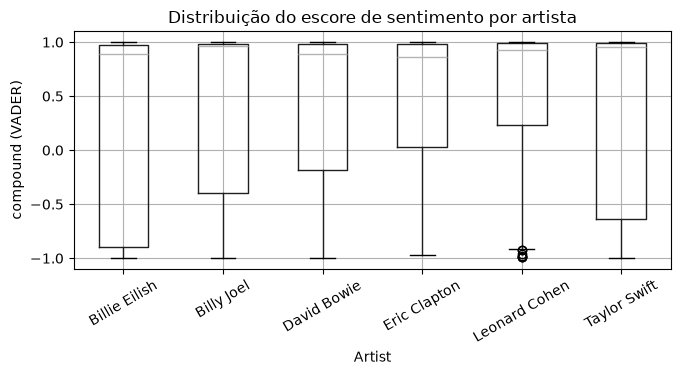

In [10]:
mais_positiva = balanced_sent.loc[balanced_sent['sentimento'].idxmax(), ['Artist', 'Title', 'sentimento']]
mais_negativa = balanced_sent.loc[balanced_sent['sentimento'].idxmin(), ['Artist', 'Title', 'sentimento']]
print('Música mais positiva:', dict(mais_positiva))
print('Música mais negativa:', dict(mais_negativa))

fig, ax = plt.subplots(figsize=(7, 4))
balanced_sent.boxplot(column='sentimento', by='Artist', ax=ax, rot=30)
ax.set_title('Distribuição do escore de sentimento por artista')
ax.set_ylabel('compound (VADER)')
fig.suptitle('')
fig.tight_layout()
plt.show()


## 7. Reconhecimento de entidades nomeadas (NER) com spaCy

Como nos slides (que usam `pt_core_news_sm` para português), aqui usamos `en_core_web_sm` — o
modelo de inglês do spaCy — para extrair candidatos a entidades da letra de "Vienna" (Billy Joel).


In [11]:
import spacy

nlp = spacy.load('en_core_web_sm')
musica = balanced[(balanced['Artist'] == 'Billy Joel') & (balanced['Title'].str.contains('Vienna', case=False))].iloc[0]
doc = nlp(musica['Lyrics'])

print('Música:', musica['Title'])
for ent in doc.ents[:15]:
    print(f'{ent.text!r} -> {ent.label_}')


Música: Vienna
'only so many hours' -> TIME
'Kick' -> PERSON
'Vienna' -> GPE
'tonight' -> TIME
'tonight' -> TIME
'Vienna' -> GPE
'day' -> DATE
'two' -> CARDINAL
'Vienna' -> GPE
'Kick' -> PERSON
'Vienna' -> GPE
'Vienna' -> GPE


## Exercício

Escolha **um** dos itens abaixo e resolva em uma nova célula, registrando sua hipótese antes de
rodar o código:

1. **Outro par de artistas:** repita a Parte 4 (similaridade) comparando duas músicas de artistas
   diferentes (em vez de duas músicas do mesmo artista). O cosseno é maior ou menor do que o
   encontrado entre "cardigan" e "exile"? Por quê?
2. **Outra fatia no sentimento:** na Parte 6, em vez de agrupar o escore de sentimento por
   artista, crie uma fatia por tamanho da letra (curta vs. longa, pela mediana de `n_words`) ou
   por década aproximada de carreira do artista (se souber), e compare as médias entre as fatias.
3. **Auditoria adicional:** procure no corpus **outro** padrão suspeito de raspagem de dados (por
   exemplo, repetições de colchetes como `[Chorus]`, `[Verse 1]`) e meça quantas músicas são
   afetadas. Vale a pena limpar antes de vetorizar? Justifique.
4. **Léxico vs. contexto:** escolha uma letra do corpus com ironia ou negação (ex.: "I'm not sad")
   e explique, usando o que discutimos nos slides sobre `LeIA`/VADER, por que um analisador léxico
   pode errar nesse caso.


### Solução do exercício 1 — outro par de artistas

**Hipótese:** por serem de artistas diferentes, espero que `cardigan` e `Vienna` tenham um cosseno menor do que `cardigan` e `exile`. Ainda assim, a comparação deve ser feita pelas palavras efetivamente compartilhadas, e não apenas pela autoria.


In [14]:
# Comparação entre músicas de artistas diferentes: Taylor Swift e Billy Joel
cross_a = songs[(songs['Artist'] == 'Taylor Swift') & (songs['Title'] == 'cardigan')]['Lyrics'].iloc[0]
cross_b = songs[(songs['Artist'] == 'Billy Joel') & (songs['Title'] == 'Vienna')]['Lyrics'].iloc[0]

tfidf_cross = TfidfVectorizer(stop_words='english')
tfidf_cross_vecs = tfidf_cross.fit_transform([cross_a, cross_b])
cos_cross = cosine_similarity(tfidf_cross_vecs[0], tfidf_cross_vecs[1])[0, 0]

count_bin_cross = CountVectorizer(stop_words='english', binary=True)
bow_bin_cross = count_bin_cross.fit_transform([cross_a, cross_b]).toarray()
jac_cross = jaccard_score(bow_bin_cross[0], bow_bin_cross[1])

count_cross = CountVectorizer(stop_words='english')
bow_cross = count_cross.fit_transform([cross_a, cross_b]).toarray()
euc_cross = euclidean_distances(bow_cross[[0]], bow_cross[[1]])[0, 0]

print('cardigan (Taylor Swift) vs Vienna (Billy Joel)')
print('cosseno (TF-IDF):', round(cos_cross, 3))
print('Jaccard (BoW binário):', round(jac_cross, 3))
print('Euclidiana (BoW contagem):', round(euc_cross, 3))
print('cosseno cardigan vs exile:', round(cos, 3))
print('Comparação:', 'maior' if cos_cross > cos else 'menor')


cardigan (Taylor Swift) vs Vienna (Billy Joel)
cosseno (TF-IDF): 0.049
Jaccard (BoW binário): 0.049
Euclidiana (BoW contagem): 24.94
cosseno cardigan vs exile: 0.046
Comparação: maior


**Interpretação:** neste corpus, o cosseno entre `cardigan` e `Vienna` é ligeiramente **maior** que o cosseno entre `cardigan` e `exile` (aproximadamente `0,049` contra `0,046`). Isso acontece porque a similaridade de TF-IDF depende do vocabulário e da frequência das palavras nas letras — não da identidade do artista. As duas músicas compartilham termos como `time`, `know`, `old`, `come` e `phone`; portanto, uma música de outro artista pode ser mais próxima lexicalmente. A diferença é pequena, então não permite concluir que Taylor Swift e Billy Joel tenham estilos iguais.

A distância Euclidiana e o índice de Jaccard complementam a análise, mas medem propriedades diferentes: a primeira considera as contagens das palavras e o segundo considera principalmente a presença ou ausência delas.


## Ponte para a Aula 02

Neste notebook, representações clássicas (BoW, TF-IDF) e um léxico de sentimento levaram a
resultados úteis, mas limitados: nenhuma dessas técnicas entende contexto, ironia ou a estrutura
poética de uma letra de música. Na Aula 02, começamos a discutir como modelos de linguagem
(LLMs) representam texto de forma diferente — e onde isso realmente ajuda em relação ao que
fizemos aqui.
